In [ ]:
# Libraries
library(tidyverse)

In [2]:
# List files
danish_annelida <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Annelida.tsv", recursive = T, full.names = T)
danish_arthropoda <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Arthropoda.tsv", recursive = T, full.names = T)
danish_chordata <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Chordata.tsv", recursive = T, full.names = T)
danish_mollusca <- list.files("12-ExtractTaxaReads/Danish", pattern = "Eukaryota_Mollusca.tsv", recursive = T, full.names = T)

exotic_annelida <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Annelida.tsv", recursive = T, full.names = T)
exotic_arthropoda <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Arthropoda.tsv", recursive = T, full.names = T)
exotic_chordata <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Chordata.tsv", recursive = T, full.names = T)
exotic_mollusca <- list.files("12-ExtractTaxaReads/Exotic", pattern = "Eukaryota_Mollusca.tsv", recursive = T, full.names = T)

# Danish
danish <- c(danish_annelida, danish_arthropoda, danish_chordata, danish_mollusca)
exotic <- c(exotic_annelida, exotic_arthropoda, exotic_chordata, exotic_mollusca)

In [ ]:
# List files
#danish <- list.files("12-ExtractTaxaReads/Danish", pattern = ".tsv", recursive = T, full.names = T)
#exotic <- list.files("12-ExtractTaxaReads/Exotic", pattern = ".tsv", recursive = T, full.names = T)

In [ ]:
# Avoid general files
#danish <- unlist(lapply(danish, function(x) if (!basename(x) %in% c("Eukaryota_Annelida.tsv","Eukaryota_Arthropoda.tsv","Eukaryota_Chordata.tsv","Eukaryota_Mollusca.tsv")) {x}))
#exotic <- unlist(lapply(exotic, function(x) if (!basename(x) %in% c("Eukaryota_Annelida.tsv","Eukaryota_Arthropoda.tsv","Eukaryota_Chordata.tsv","Eukaryota_Mollusca.tsv")) {x}))

In [3]:
# Read data: danish (~3 min)
danish <- lapply(danish, function(x) read.table(x, header=T) %>%
         mutate(category = str_split_i(x, "/", 2),
                sample = str_split_i(x, "/", 3),
                phylum = str_split_i(str_replace(str_split_i(x, "/", 4), ".tsv", ""), "_", 2))
)

In [4]:
# Read data: exotic
exotic <- lapply(exotic, function(x) read.table(x, header=T) %>%
                   mutate(category = str_split_i(x, "/", 2),
                          sample = str_split_i(x, "/", 3),
                          phylum = str_split_i(str_replace(str_split_i(x, "/", 4), ".tsv", ""), "_", 2))
)

In [5]:
# Reduce data (~4 min)
danish <- Reduce(function(...) rbind(...), danish)
exotic <- Reduce(function(...) rbind(...), exotic)

In [6]:
dim(danish)
dim(exotic)

[1] 26715909       21

[1] 318499     21

In [6]:
# Merge data
df <- rbind(danish, exotic)

In [7]:
# Rename samples
df <- df %>%
  mutate(sample = recode(sample, 
                         "GP_1" = "EN0.2A", "GP_2" = "EN0.2B", "GP_3" = "EN0.2C",
                         "A0_2" = "OP0.2A", "B0_2" = "OP0.2B", "C0_2" = "OP0.2C",
                         "A1_2" = "OP1.2A", "B1_2" = "OP1.2B", "C1_2" = "OP1.2C",
                         "A5_0" = "OP5.0A", "B5_0" = "OP5.0B", "C5_0" = "OP5.0C",
                         "A8_0" = "OP8.0A", "B8_0" = "OP8.0B", "C8_0" = "OP8.0C"),
				 pore = recode(sample, 
                         "EN0.2A" = "EN0.2", "EN0.2B" = "EN0.2", "EN0.2C" = "EN0.2",
                         "OP0.2A" = "OP0.2", "OP0.2B" = "OP0.2", "OP0.2C" = "OP0.2",
                         "OP1.2A" = "OP1.2", "OP1.2B" = "OP1.2", "OP1.2C" = "OP1.2",
                         "OP5.0A" = "OP5.0", "OP5.0B" = "OP5.0", "OP5.0C" = "OP5.0",
                         "OP8.0A" = "OP8.0", "OP8.0B" = "OP8.0", "OP8.0C" = "OP8.0"),
				 label = recode(phylum, "Chordata" = "Actinopterygii",
				                        "Mollusca" = "Bivalvia",
																"Annelida" = "Polychaeta",
																"Arthropoda" = "Malacostraca"))

In [44]:
# Check mean e-value
df_eval <- df %>% group_by(category, label, pore) %>% summarize(mean_eval = mean(evalue))
df_eval <- df_eval %>% pivot_wider(id_cols = c(label, pore), names_from = category, values_from = mean_eval)
df_eval <- df_eval %>% pivot_wider(id_cols = label, values_from = c(Danish,Exotic), names_from = pore)
df_eval

`summarise()` has grouped output by 'category', 'label'. You can override using the `.groups`
argument.


label,Danish_EN0.2,Danish_OP0.2,Danish_OP1.2,Danish_OP5.0,Danish_OP8.0,Exotic_EN0.2,Exotic_OP0.2,Exotic_OP1.2,Exotic_OP5.0,Exotic_OP8.0
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinopterygii,2.181843e-28,2.248968e-28,2.287124e-28,8.965033e-28,1.565439e-28,7.817662e-29,9.995065e-29,1.317242e-28,1.701453e-28,1.647898e-28
Bivalvia,3.613284e-31,2.751872e-30,1.208169e-29,6.324165e-30,8.832554e-30,4.515735e-33,6.809101e-34,3.460460e-32,6.928723e-31,1.338831e-32
Malacostraca,4.965843e-48,8.336635e-46,4.145507e-36,1.084441e-41,1.256839e-35,1.580769e-33,1.347368e-44,6.254335e-37,6.811999e-59,2.003977e-44
Polychaeta,1.168100e-48,2.043307e-32,1.414053e-43,9.897501e-34,2.561783e-37,6.865517e-74,9.113000e-94,1.330435e-71,1.927273e-56,1.849289e-51


In [45]:
# Check mean pident
df_pide <- df %>% group_by(category, label, pore) %>% summarize(mean_pident = mean(pident))
df_pide <- df_pide %>% pivot_wider(id_cols = c(label, pore), names_from = category, values_from = mean_pident)
df_pide <- df_pide %>% pivot_wider(id_cols = label, values_from = c(Danish,Exotic), names_from = pore)
df_pide

`summarise()` has grouped output by 'category', 'label'. You can override using the `.groups`
argument.


label,Danish_EN0.2,Danish_OP0.2,Danish_OP1.2,Danish_OP5.0,Danish_OP8.0,Exotic_EN0.2,Exotic_OP0.2,Exotic_OP1.2,Exotic_OP5.0,Exotic_OP8.0
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinopterygii,93.50991,93.01534,93.36717,93.19795,93.29532,93.46167,91.81080,92.46006,93.50827,92.86823
Bivalvia,96.39565,97.21685,96.18638,96.09764,96.32173,96.10261,95.91676,95.75287,96.29512,96.17106
Malacostraca,92.44714,92.32236,92.38744,92.54124,96.72882,96.05283,95.57723,93.79699,94.02425,92.38761
Polychaeta,96.66282,95.23590,96.32390,95.85627,97.23231,94.51131,94.59069,95.63535,94.23636,95.72062


In [47]:
# Check mean length
df_alen <- df %>% group_by(category, label, pore) %>% summarize(mean_alength = mean(length))
df_alen <- df_alen %>% pivot_wider(id_cols = c(label, pore), names_from = category, values_from = mean_alength)
df_alen <- df_alen %>% pivot_wider(id_cols = label, values_from = c(Danish,Exotic), names_from = pore)
df_alen

`summarise()` has grouped output by 'category', 'label'. You can override using the `.groups`
argument.


label,Danish_EN0.2,Danish_OP0.2,Danish_OP1.2,Danish_OP5.0,Danish_OP8.0,Exotic_EN0.2,Exotic_OP0.2,Exotic_OP1.2,Exotic_OP5.0,Exotic_OP8.0
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinopterygii,197.7421,197.4910,205.3575,202.2369,189.2879,218.1826,213.9604,208.1956,199.2304,185.7141
Bivalvia,217.5004,224.3569,217.6811,209.8256,201.6225,217.8422,237.4664,226.0320,225.9829,207.1217
Malacostraca,213.0756,235.2243,218.1783,219.6020,229.3172,227.2077,238.2737,228.0231,224.2152,192.9114
Polychaeta,213.3233,228.4252,225.3720,214.3902,197.4057,228.2069,236.6923,230.6522,214.0000,192.8081


In [49]:
# Check mean mismatches
df_mism <- df %>% group_by(category, label, pore) %>% summarize(mean_mismatch = mean(mismatch))
df_mism <- df_mism %>% pivot_wider(id_cols = c(label, pore), names_from = category, values_from = mean_mismatch)
df_mism <- df_mism %>% pivot_wider(id_cols = label, values_from = c(Danish,Exotic), names_from = pore)
df_mism

`summarise()` has grouped output by 'category', 'label'. You can override using the `.groups`
argument.


label,Danish_EN0.2,Danish_OP0.2,Danish_OP1.2,Danish_OP5.0,Danish_OP8.0,Exotic_EN0.2,Exotic_OP0.2,Exotic_OP1.2,Exotic_OP5.0,Exotic_OP8.0
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinopterygii,10.913020,12.153891,11.575781,11.708985,10.793276,13.170025,15.772269,14.566926,11.375065,12.349140
Bivalvia,6.422881,4.716743,6.386782,6.636676,6.104381,7.473010,7.440044,7.736192,6.566867,6.433655
Malacostraca,14.683473,17.065421,15.089161,15.386779,6.735821,8.365385,9.642105,13.803468,12.708861,14.215190
Polychaeta,6.521184,9.740157,7.602151,8.007505,5.069797,10.620690,12.538462,9.130435,10.818182,7.273256


In [ ]:
# Check mean gaps
df_gaps <- df %>% group_by(category, label, pore) %>% summarize(mean_gaps = mean(gapopen))
df_gaps <- df_gaps %>% pivot_wider(id_cols = c(label, pore), names_from = category, values_from = mean_gaps)
df_gaps <- df_gaps %>% pivot_wider(id_cols = label, values_from = c(Danish,Exotic), names_from = pore)
df_gaps

`summarise()` has grouped output by 'category', 'label'. You can override using the `.groups`
argument.


label,Danish_EN0.2,Danish_OP0.2,Danish_OP1.2,Danish_OP5.0,Danish_OP8.0,Exotic_EN0.2,Exotic_OP0.2,Exotic_OP1.2,Exotic_OP5.0,Exotic_OP8.0
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinopterygii,1.255576,1.188142,1.307691,1.391526,1.2729173,1.0187922,1.7446249,1.1811744,1.190133,1.0205701
Bivalvia,1.284408,1.339449,1.836530,1.575985,1.4440970,1.3936464,1.4220378,1.7375250,1.807159,1.6997208
Malacostraca,1.613839,1.464998,1.768006,1.338977,0.9323645,0.7884298,0.8586559,0.7147647,1.152450,0.8133102
Polychaeta,1.122856,1.833759,1.318712,1.038955,0.9307443,1.8642343,0.5063697,1.1862186,2.174727,1.4057618


In [8]:
# Compute correlation (More Danish == More Exotic?)
df_cor <- df %>% group_by(category, sample, label, pore) %>% summarize(no_of_reads = n())
df_cor <- df_cor %>% pivot_wider(id_cols = c(sample, label, pore), names_from = category, values_from = no_of_reads)
head(df_cor)

df_cor %>% group_by(label, pore) %>% summarise(Danish = mean(Danish), Exotic = mean(Exotic)) %>%
pivot_wider(id_cols = "label", values_from = c("Danish","Exotic"), names_from = "pore")

`summarise()` has grouped output by 'category', 'sample',
'label'. You can override using the `.groups` argument.


sample,label,pore,Danish,Exotic
<chr>,<chr>,<chr>,<int>,<int>
EN0.2A,Actinopterygii,EN0.2,1012090,7749
EN0.2A,Bivalvia,EN0.2,3688,621
EN0.2A,Malacostraca,EN0.2,79,83
EN0.2A,Polychaeta,EN0.2,218,2
EN0.2B,Actinopterygii,EN0.2,1934240,16426
EN0.2B,Bivalvia,EN0.2,2090,690


`summarise()` has grouped output by 'label'. You can
override using the `.groups` argument.


label,Danish_EN0.2,Danish_OP0.2,Danish_OP1.2,Danish_OP5.0,Danish_OP8.0,Exotic_EN0.2,Exotic_OP0.2,Exotic_OP1.2,Exotic_OP5.0,Exotic_OP8.0
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinopterygii,1105504.3333,319693.66667,2555058.0000,1732066.33,3134385.6667,9032.000000,7664.00000,15146.000000,23824.333333,37916.00000
Bivalvia,4050.0000,2984.33333,8650.0000,15701.33,21677.0000,728.666667,606.00000,2106.333333,3778.666667,5049.33333
Malacostraca,119.0000,71.33333,190.6667,237.00,893.3333,86.666667,31.66667,57.666667,26.333333,26.33333
Polychaeta,574.3333,84.66667,465.0000,533.00,2364.0000,9.666667,NA,7.666667,7.333333,57.33333


-------

*Testing Danish versus Exotic hits*

In [ ]:
library(effsize)

In [215]:
# Variables
samples <- c("EN0.2A","EN0.2B","EN0.2C","OP0.2A","OP0.2B","OP0.2C","OP1.2A","OP1.2B","OP1.2C","OP5.0A","OP5.0B","OP5.0C","OP8.0A","OP8.0B","OP8.0C")
clades <- c("Polychaeta","Malacostraca","Bivalvia","Actinopterygii")

In [ ]:
# Wilcoxon test for Danish larger than Exotic -> Perc. of identity (~10 min)
# Store results
res <- list()
# Loop samples
for (s in samples) {
	# Report
	message(paste("Processing:", s ,"..."))
	# Loop clades
	for (c in clades) {
		sub <- subset(df, sample == s & label == c)
		# Check if comparison is possible
		if ("Danish" %in% unique(sub$category) & "Exotic" %in% unique(sub$category)) {
			# Categories to factor
			sub$category <- factor(sub$category, levels = c("Danish","Exotic"))
			# Compute count and percentage
			cs <- table(sub$category)
			ms <- tapply(sub$pident, sub$category, mean)
			# Wilcoxon test
			wx <- wilcox.test(pident ~ category, data = sub, alternative = "greater")
			# Cliff's delta (Effect size)
			cld <- cliff.delta(pident ~ category, data = sub)
			# Append results
			res[[length(res)+1]] <- c(s, c, cs[[1]], cs[[2]], ms[[1]], ms[[2]], cld$estimate, wx$statistic[[1]], wx$p.value)
		}
	}
}

# Wilcoxon dataframe
df_wx_pide <- data.frame(do.call(rbind, res))
colnames(df_wx_pide) <- c("sample","clade","danish_entries","exotic_entries","danish_mean","exotic_mean", "cliffs_delta","statistic","pvalue")
df_wx_pide$adj_pvalue <- p.adjust(df_wx_pide$pvalue, method = "BH")

# Save results
write.table(df_wx_pide, "12-ExtractTaxaReads/pident_wilcox_cliff.tsv", sep="\t", row.names = F, quote = F)

In [ ]:
# Wilcoxon test for Danish larger than Exotic -> Alignment length (~20 min)
# Store results
res <- list()
# Loop samples
for (s in samples) {
	# Report
	message(paste("Processing:", s ,"..."))
	# Loop clades
	for (c in clades) {
		sub <- subset(df, sample == s & label == c)
		# Check if comparison is possible
		if ("Danish" %in% unique(sub$category) & "Exotic" %in% unique(sub$category)) {
			# Categories to factor
			sub$category <- factor(sub$category, levels = c("Danish","Exotic"))
			# Compute count and percentage
			cs <- table(sub$category)
			ms <- tapply(sub$length, sub$category, mean)
			# Wilcoxon test
			wx <- wilcox.test(length ~ category, data = sub, alternative = "greater")
			# Cliff's delta (Effect size)
			cld <- cliff.delta(length ~ category, data = sub)
			# Append results
			res[[length(res)+1]] <- c(s, c, cs[[1]], cs[[2]], ms[[1]], ms[[2]], cld$estimate, wx$statistic[[1]], wx$p.value)
		}
	}
}

# Wilcoxon dataframe
df_wx_alen <- data.frame(do.call(rbind, res))
colnames(df_wx_alen) <- c("sample","clade","danish_entries","exotic_entries","danish_mean","exotic_mean", "cliffs_delta","statistic","pvalue")
df_wx_alen$adj_pvalue <- p.adjust(df_wx_alen$pvalue, method = "BH")

# Save results
write.table(df_wx_alen, "12-ExtractTaxaReads/alnlen_wilcox_cliff.tsv", sep="\t", row.names = F, quote = F)

In [ ]:
# Wilcoxon test for Danish larger than Exotic -> Mismatches (~20 min)
# Store results
res <- list()
# Loop samples
for (s in samples) {
	# Report
	message(paste("Processing:", s ,"..."))
	# Loop clades
	for (c in clades) {
		sub <- subset(df, sample == s & label == c)
		# Check if comparison is possible
		if ("Danish" %in% unique(sub$category) & "Exotic" %in% unique(sub$category)) {
			# Categories to factor
			sub$category <- factor(sub$category, levels = c("Danish","Exotic"))
			# Compute count and percentage
			cs <- table(sub$category)
			ms <- tapply(sub$mismatch, sub$category, mean)
			# Wilcoxon test
			wx <- wilcox.test(mismatch ~ category, data = sub, alternative = "less")
			# Cliff's delta (Effect size)
			cld <- cliff.delta(mismatch ~ category, data = sub)
			# Append results
			res[[length(res)+1]] <- c(s, c, cs[[1]], cs[[2]], ms[[1]], ms[[2]], cld$estimate, wx$statistic[[1]], wx$p.value)
		}
	}
}

# Wilcoxon dataframe
df_wx_mism <- data.frame(do.call(rbind, res))
colnames(df_wx_mism) <- c("sample","clade","danish_entries","exotic_entries","danish_mean","exotic_mean", "cliffs_delta","statistic","pvalue")
df_wx_mism$adj_pvalue <- p.adjust(df_wx_mism$pvalue, method = "BH")

# Save results
write.table(df_wx_mism, "12-ExtractTaxaReads/mismatch_wilcox_cliff.tsv", sep="\t", row.names = F, quote = F)

In [234]:
df_wx_pide %>% filter(adj_pvalue < 0.05, as.numeric(cliffs_delta) > 0.33, as.numeric(exotic_entries) > 100)
df_wx_alen %>% filter(adj_pvalue < 0.05, as.numeric(cliffs_delta) > 0.33, as.numeric(exotic_entries) > 100)
df_wx_mism %>% filter(adj_pvalue < 0.05, as.numeric(cliffs_delta) > 0.33, as.numeric(exotic_entries) > 100)

sample,clade,danish_entries,exotic_entries,danish_mean,exotic_mean,cliffs_delta,statistic,pvalue,adj_pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
EN0.2A,Actinopterygii,1012090,7749,93.3142979033485,92.0050672344819,0.368567518762684,5366622256,0,0.000000e+00
OP0.2A,Bivalvia,2675,428,97.9492945794393,95.5202289719626,0.561851690103939,894082,1.00211656711809e-84,4.223206e-84
OP0.2A,Actinopterygii,539269,11755,92.9489930016374,91.6208727350064,0.445018119700974,4580062307.5,0,0.000000e+00
OP0.2C,Bivalvia,3657,580,97.5878698386656,96.0356517241379,0.410700781684629,1496090.5,2.3467738562665e-58,8.144686e-58
OP0.2C,Actinopterygii,202301,6593,93.261397827989,91.9514057333536,0.343648888924701,896059620.5,0,0.000000e+00
OP1.2B,Bivalvia,6670,1647,96.9511413793103,95.5856017000607,0.332784518487569,7320645.5,4.84103092423103e-98,2.197083e-97


sample,clade,danish_entries,exotic_entries,danish_mean,exotic_mean,cliffs_delta,statistic,pvalue,adj_pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>


sample,clade,danish_entries,exotic_entries,danish_mean,exotic_mean,cliffs_delta,statistic,pvalue,adj_pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>


------------

In [9]:
# Correlation per phylum
df_cor %>%
  group_by(label) %>%
  summarise(correlation = cor(Danish, Exotic, method = "pearson", use = "complete.obs")*100)

label,correlation
<chr>,<dbl>
Actinopterygii,71.29148
Bivalvia,95.19238
Malacostraca,-19.65818
Polychaeta,98.81431


In [10]:
# Correlation per filter
df_cor %>%
  group_by(pore) %>%
  summarise(correlation = cor(Danish, Exotic, method = "pearson", use = "complete.obs")*100)

pore,correlation
<chr>,<dbl>
EN0.2,99.67999
OP0.2,98.50618
OP1.2,83.12926
OP5.0,92.92692
OP8.0,98.60601


In [18]:
# Plot correlation pattern
p <- df_cor %>% ggplot(aes(x=log(Exotic), y=log(Danish), fill=pore, shape=label, color=pore)) +
geom_point(size=2) +
labs(color="Filter type", shape="Group", x="No .of Exotic reads (Log)", y="No. of Danish reads (Log)") +
guides(fill="none") +
ylim(0,NA) +
scale_shape_manual(values = c(21,25,24,22)) +
scale_color_manual(values = c('#f8766d','#b79f00','#00bf7d','#00b0f6','#e76bf3')) +
scale_fill_manual(values = c('#f8766d','#b79f00','#00bf7d','#00b0f6','#e76bf3')) +
theme_bw(base_size = 12)

png(file="12-ExtractTaxaReads/cor_reads.danish_vs_exotic.png", width = 1500, height = 1200, res=300)
p
dev.off()

Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”


png 
  2

In [ ]:
# Summarize data
nreads <- df %>% group_by(category, sample, label) %>% summarize(count = n()) %>%
nreads$pore <- factor(nreads$pore, levels = c('EN0.2', 'OP0.2', 'OP1.2', 'OP5.0', 'OP8.0'))
head(nreads)

`summarise()` has grouped output by 'category', 'sample'. You can override using the `.groups`
argument.


category,sample,label,count,group
<chr>,<chr>,<chr>,<int>,<fct>
Danish,EN0.2A,Actinopterygii,1012090,EN0.2
Danish,EN0.2A,Bivalvia,3688,EN0.2
Danish,EN0.2A,Malacostraca,79,EN0.2
Danish,EN0.2A,Polychaeta,218,EN0.2
Danish,EN0.2B,Actinopterygii,1934240,EN0.2
Danish,EN0.2B,Bivalvia,2090,EN0.2


In [ ]:
# Plot read counts
p <- nreads %>% ggplot() + geom_boxplot(aes(x=pore, y=log10(count), color=category)) +
facet_grid(label~pore, scales = "free") +
scale_color_manual(values = c("darkred","grey25")) +
ylim(0,NA) +
labs(x="", y="No. of reads (Log10)", color="") +
theme_bw() %+replace% theme(axis.text.x = element_text(angle = 90), legend.position = "top")

png(file="12-ExtractTaxaReads/num_reads.png", width = 1200, height = 1500, res=300)
p
dev.off()

png 
  2

In [ ]:
p <- df %>% ggplot() +
geom_violin(aes(x=sample, y=-log10(evalue + 1e-300), fill=category), color="black") +
scale_fill_manual(values = c("darkred","grey25")) +
labs(x="", y="E-value (-Log10)", color="") +
facet_grid(label~pore, scales = "free_x") +
theme_bw() %+replace% theme(axis.text.x = element_text(angle = 90),legend.position = "top")

png(file="12-ExtractTaxaReads/evalue_violins.png", width = 1400, height = 1500, res=300)
p
dev.off()

Warning message:
“Groups with fewer than two data points have been dropped.”


png 
  2

Warning message:
“Groups with fewer than two data points have been dropped.”


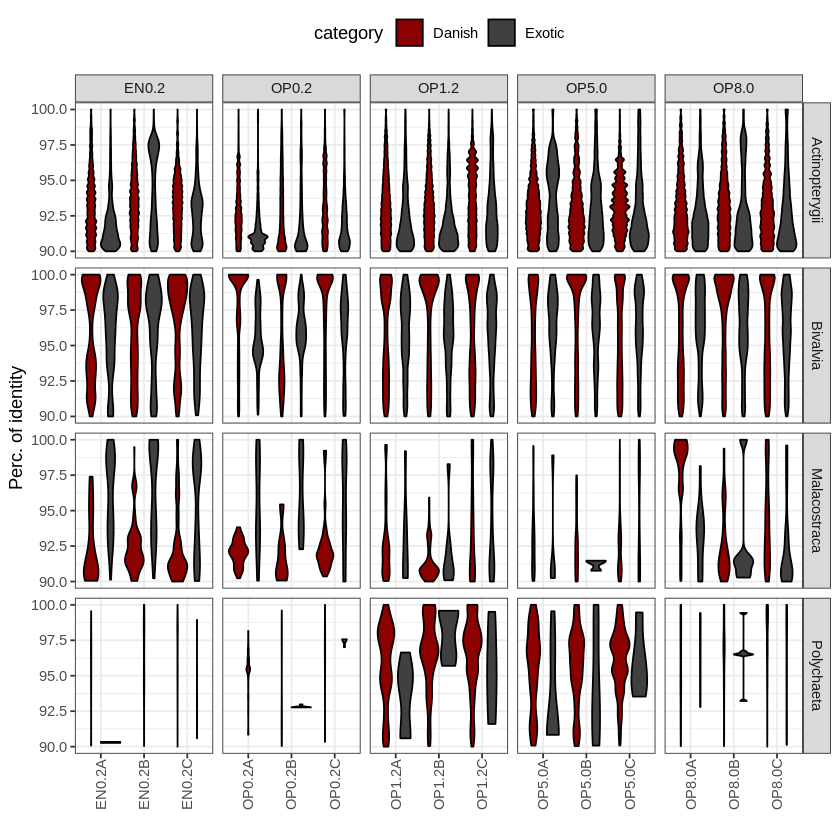

In [ ]:
df %>% ggplot() +
geom_violin(aes(x=sample, y=pident, fill=category), color="black") +
scale_fill_manual(values = c("darkred","grey25")) +
labs(x="", y="Perc. of identity", color="") +
facet_grid(label~pore, scales = "free_x") +
theme_bw() %+replace% theme(axis.text.x = element_text(angle = 90),legend.position = "top")

Warning message:
“Groups with fewer than two data points have been dropped.”


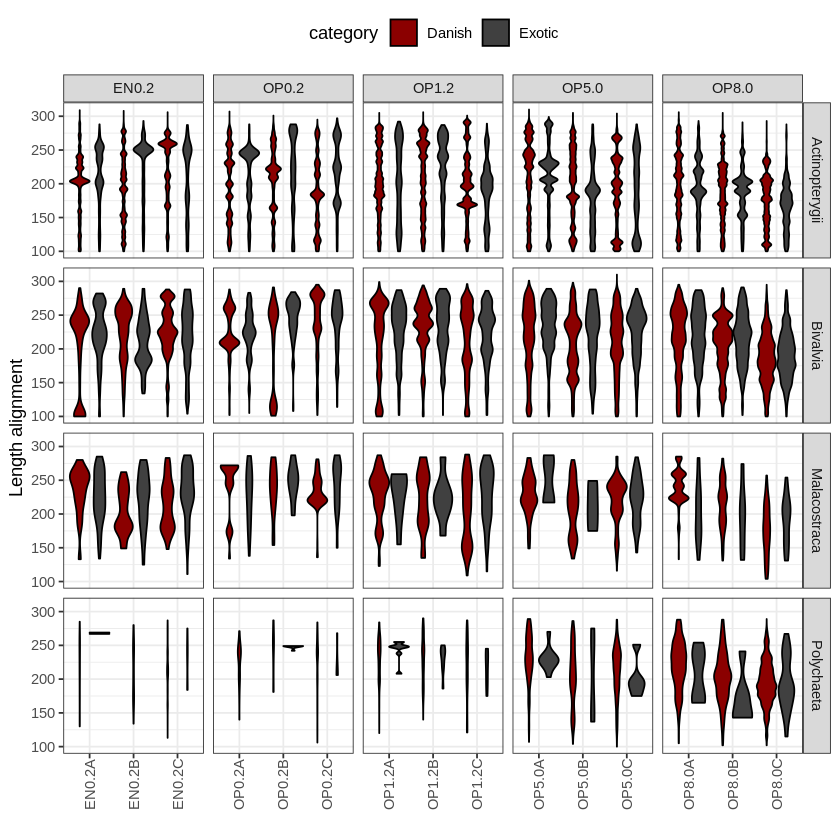

In [ ]:
df %>% ggplot() +
geom_violin(aes(x=sample, y=length, fill=category), color="black") +
scale_fill_manual(values = c("darkred","grey25")) +
labs(x="", y="Length alignment", color="") +
facet_grid(label~pore, scales = "free_x") +
theme_bw() %+replace% theme(axis.text.x = element_text(angle = 90),legend.position = "top")

Warning message:
“Groups with fewer than two data points have been dropped.”


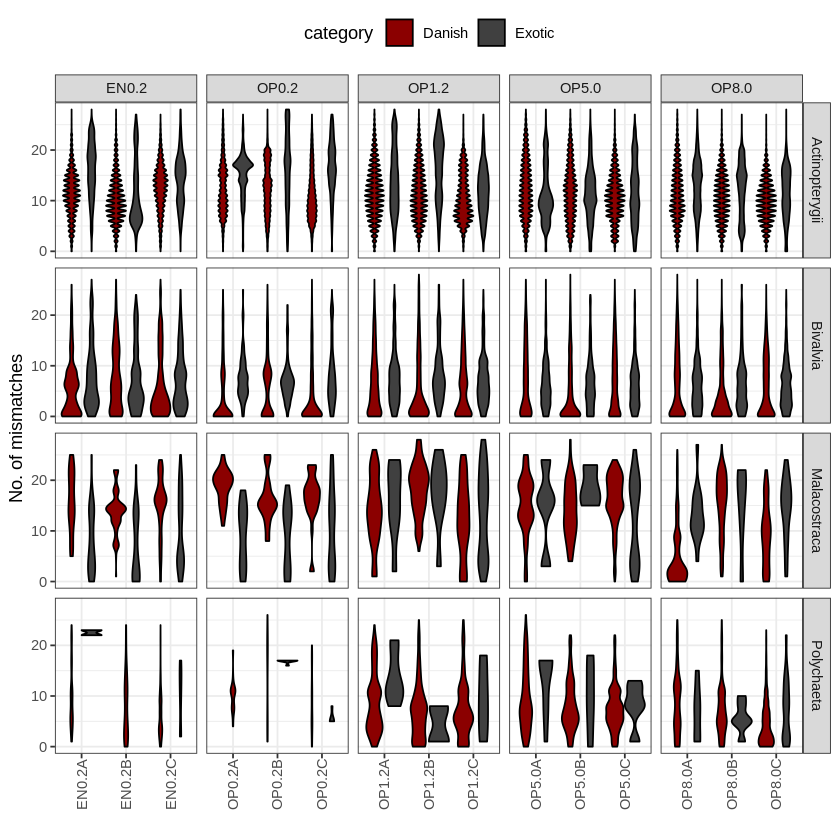

In [ ]:
df %>% ggplot() +
geom_violin(aes(x=sample, y=mismatch, fill=category), color="black") +
scale_fill_manual(values = c("darkred","grey25")) +
labs(x="", y="No. of mismatches", color="") +
facet_grid(label~pore, scales = "free_x") +
theme_bw() %+replace% theme(axis.text.x = element_text(angle = 90),legend.position = "top")

-------

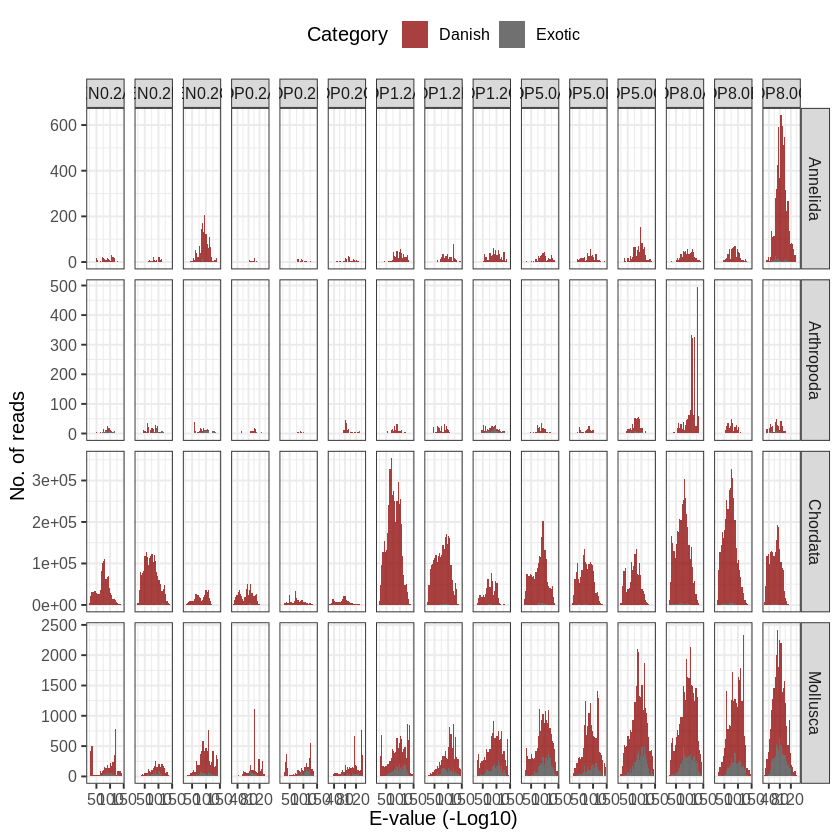

In [47]:
# Plot e-value (zero-handling) distributions
p <- df %>% ggplot() + geom_histogram(aes(x=-log10(evalue + 1e-300), fill=category), alpha=0.75, bins = 30) +
facet_grid(phylum~sample, scales = "free") +
scale_fill_manual(values = c("darkred","gray25")) +
labs(x="E-value (-Log10)", y="No. of reads", fill="Category") +
theme_bw(base_size = 12) %+replace% theme(legend.position = "top")

#png(file="12-ExtractTaxaReads/evalue_per_sample.png", width = 4000, height = 1800, res=300)
p
#dev.off()

In [ ]:
# Plot pident distributions
p <- df %>% ggplot() + geom_histogram(aes(x=pident, fill=category), alpha=0.75, bins = 30) +
facet_grid(phylum~sample, scales = "free") +
scale_fill_manual(values = c("darkred","gray25")) +
labs(x="Percentage of identity", y="No. of reads", fill="Category") +
theme_bw(base_size = 12) %+replace% theme(legend.position = "top",
										  axis.text.x = element_text(angle = 45, size = 8, vjust=1, hjust=1))

png(file="12-ExtractTaxaReads/pident_per_sample.png", width = 4000, height = 1800, res=300)
p
dev.off()

png 
  2

In [24]:
# plot length vs mismatch (~7 min)
p <- df %>% ggplot() + geom_point(aes(y=as.numeric(length), x=as.numeric(mismatch), color=category), alpha=0.25) +
facet_grid(phylum~sample, scales = "free") +
scale_color_manual(values = c("darkred","gray25")) +
labs(x="No. of mistmatches", y="Alignment length", fill="Category") +
theme_bw(base_size = 12) %+replace% theme(legend.position = "top")

png(file="12-ExtractTaxaReads/aln_vs_mismatch_per_sample.png", width = 4000, height = 1800, res=300)
p
dev.off()

png 
  2

--------

*Linear model*

In [ ]:
library(lme4)

In [24]:
head(df,3)

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,⋯,qlen,qcovs,qcovhsp,qcovus,taxid,category,sample,phylum,pore,label
,<chr>,<chr>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,A00551:49:HF7V2DSXX:3:1309:20546:27305,HQ691220.1,94.915,236,12,0,1,236,2723,2488,⋯,237,99,99,99,6344,Danish,OP0.2A,Annelida,OP0.2,Polychaeta
2,A00551:49:HF7V2DSXX:3:1316:12228:35540,AY577893.1,96.059,203,8,0,9,211,106,308,⋯,211,96,96,96,1037239,Danish,OP0.2A,Annelida,OP0.2,Polychaeta
3,A00551:49:HF7V2DSXX:3:1316:12228:35540,DQ790094.1,96.059,203,8,0,9,211,1677,1475,⋯,211,96,96,96,1037239,Danish,OP0.2A,Annelida,OP0.2,Polychaeta


In [ ]:
# Fit model (Fix effect: category and phylum ; Random effect: pore)
# Response (Dependent) ~ Predictors (Independent)
glmm_fit <- glmer(
  length ~ category + label + (1 | pore),
  family = Gamma(link = "log"),
  data = df
)

summary(glmm_fit)

-------

In [ ]:
x <- df %>% select(qseqid, pident, length, mismatch, gapopen, category, sample, label) %>%
mutate(length = length/max(length) * 100, mismatch = mismatch / max(mismatch)*100, gapopen = gapopen / max(gapopen)*100)

x <- scale(x[,c('pident','length','mismatch','gapopen')])

In [ ]:
pca = prcomp(t(x))
pca <- cbind(df %>% select(qseqid, sample, label, category), pca$rotation)

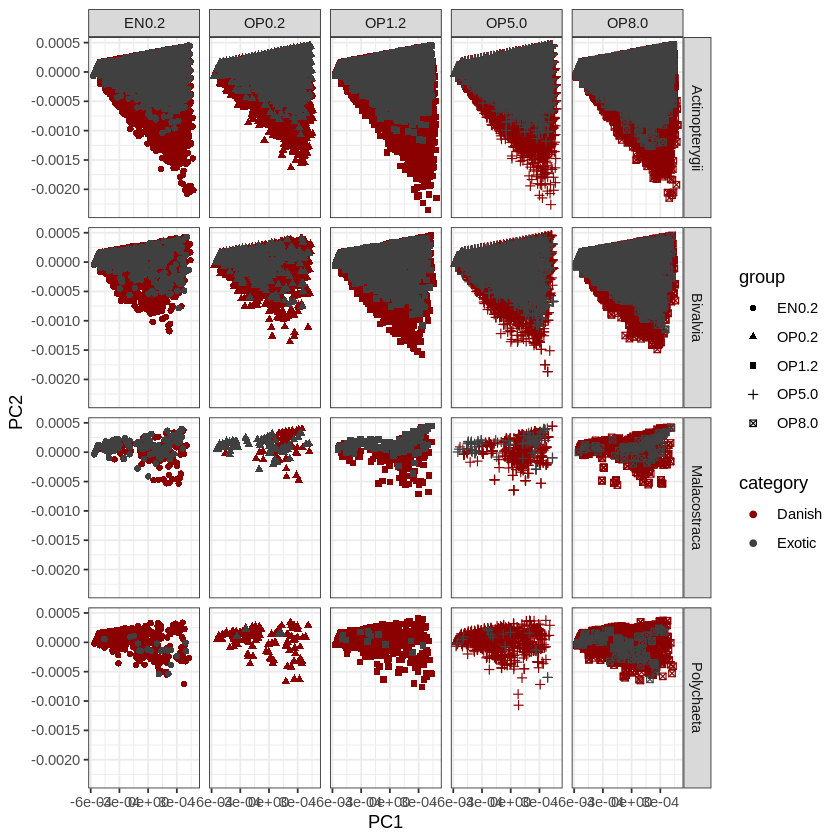

In [158]:
pca %>% mutate(group = recode(sample, 
                         "EN0.2A" = "EN0.2", "EN0.2B" = "EN0.2", "EN0.2C" = "EN0.2",
                         "OP0.2A" = "OP0.2", "OP0.2B" = "OP0.2", "OP0.2C" = "OP0.2",
                         "OP1.2A" = "OP1.2", "OP1.2B" = "OP1.2", "OP1.2C" = "OP1.2",
                         "OP5.0A" = "OP5.0", "OP5.0B" = "OP5.0", "OP5.0C" = "OP5.0",
                         "OP8.0A" = "OP8.0", "OP8.0B" = "OP8.0", "OP8.0C" = "OP8.0")) %>%
ggplot() + geom_point(aes(x=PC1, y=PC2, shape=group, color=category)) +
scale_color_manual(values = c("darkred","gray25")) +
facet_grid(label~group) +
theme_bw()